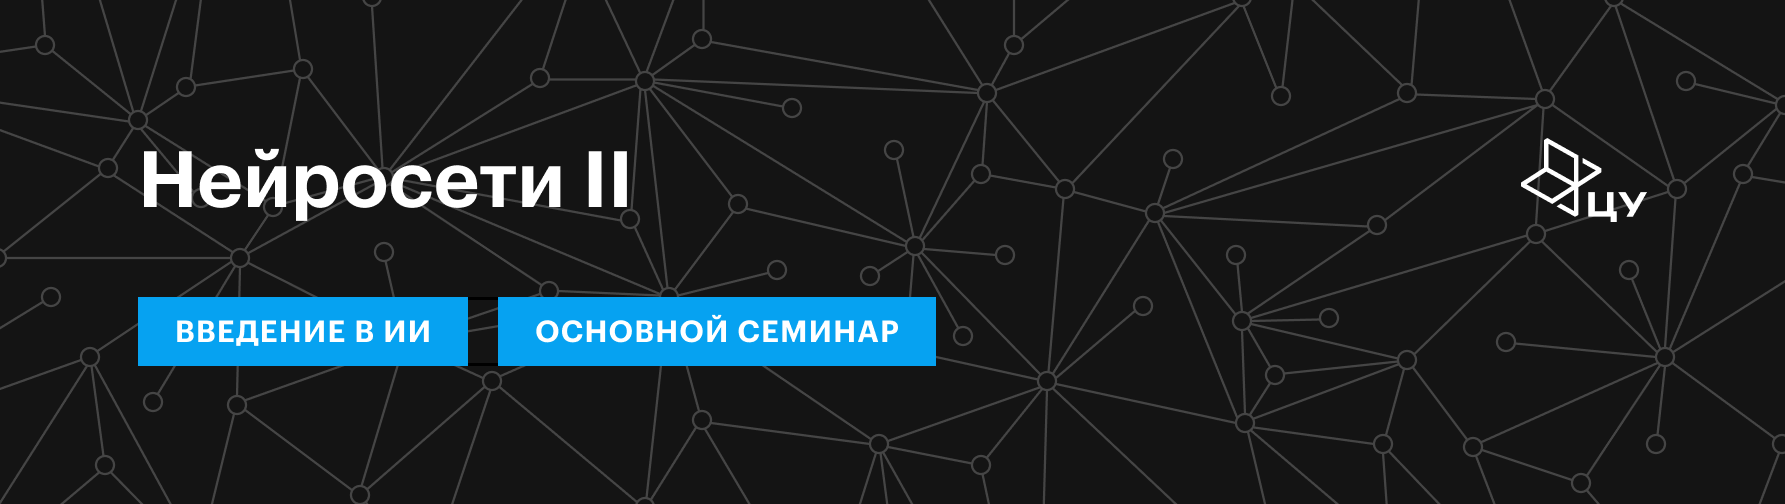

# Семинар по теме «Нейросети II»

На прошлом занятии мы разбирали основы нейросетей, экспериментировали и пытались их проинтерпретировать. Пришло время перейти к настоящей задаче глубинного обучения — сегодня ты изучишь, как обучаются и работают нейросети.

Из этого семинара ты узнаешь:
- зачем нужен DataLoader;
- как написать код для обучения нейросети;
- как создать собственную нейросеть и решить задачу с её помощью.

##Подготовка

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn

import warnings
warnings.filterwarnings("ignore")

### Оформление данных для нейросети

Разберём популярную задачу, которую часто используют на начальных этапах изучения работы нейросетей. Это распознавание датасета MNIST, который содержит изображения рукописных цифр размером $28 \times 28$. В этой задаче нужно предсказать, какая цифра от 0 до 9 представлена на изображении.

Задачу предсказания MNIST относят к категории компьютерного зрения.

> **Компьютерное зрение** — это раздел глубокого обучения, который работает с картинками и видео.

Более подробно компьютерное зрение мы разберём через пару недель. А пока попробуем решить эту задачу при помощи уже хорошо освоенного инструмента — полносвязных нейронных сетей.

Загрузим датасет. В PyTorch для этого уже реализована функция:

In [2]:
from torchvision.datasets import MNIST
import numpy as np

In [3]:
# Загружаем датасет
train_ = MNIST('/content', # Папка для сохранения или загрузки
              download=True, # Если нет в папке, скачиваем из интернета
              train=True) # train-подвыборка
test = MNIST('/content', download=True, train=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.12MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.66MB/s]


Датасет готов к работе. При этом данные представлены не в виде списка или массива, а классом `Dataset`, который необходим для обучения нейросети.

In [4]:
train_

Dataset MNIST
    Number of datapoints: 60000
    Root location: /content
    Split: Train

Конкретный класс `Dataset` содержит больше методов, чем необходимо. Но для работы с данными достаточно реализовать два метода:

1. `__len__` — метод, который определяет длину нашего датасета. Он показывает, сколько наблюдений в него входит.
2. `__getitem__` — метод, который по индексу достаёт из датасета наблюдение. Он соответствует обращению к объекту через [...]. Например, к списку `lst[id]` или к словарю `dct[key]`.

Проверим, что в нашей train-подвыборке эти методы реализованы.

In [5]:
# Количество наблюдений в train-подвыборке
len(train_)

60000

In [6]:
# Можно достать n-й элемент
train_[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

Теперь посмотрим, что содержится в этом *n*-м элементе:

1. Картинка с нашим числом в формате PIL (это название библиотеки для обработки изображений).
2. Таргет (целевая переменная) для картинки.

Посмотрим на нашу картинку.

In [7]:
# Можно просто достать картинку из кортежа, PIL её отрисует, но получается некрасиво. Воспользуемся Matplotlib
train_[0][0]

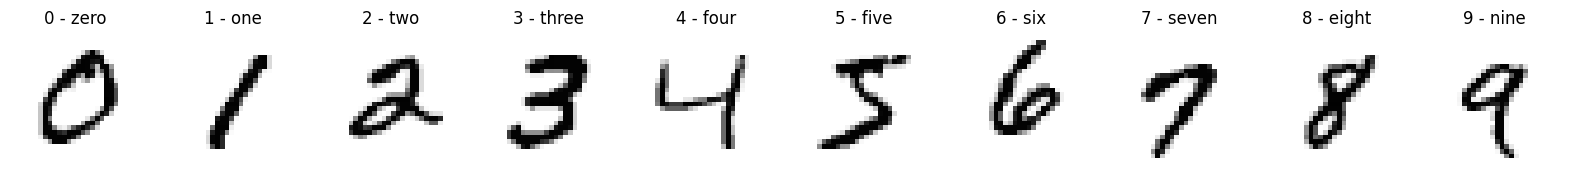

In [8]:
# Это функция для отрисовки изображения. Можешь изучить, что здесь происходит, но это не так важно


import matplotlib.pyplot as plt

def show_ds(ds, n=0, preds=None): # Принимает датасет, номер изображения из класса и предсказания, если хотим их добавить в название
    # Хотим получить по изображению каждого класса
    fig, axs = plt.subplots(1, len(ds.classes), figsize=(20, 5))
    # Итерируемся по каждому классу
    for cls_num, name in enumerate(ds.classes):
        # Берём n-е изображение класса в датасете
        i = np.argwhere(ds.targets == cls_num)[0][n]
        inverted = 255 - ds.data[i] # На белом фоне выглядит лучше. Но для алгоритмов разницы нет
        # Рисуем изображение
        ax = axs[cls_num]
        ax.imshow(inverted, cmap="Greys_r")

        pred_cls = ''
        if preds is not None:
          pred_cls += f' Pred: {preds[i]}'

        ax.set_title(name + pred_cls)
        ax.axis("off")
    plt.show()

# Рисуем
show_ds(train_)

In [9]:
# Для начала достанем все данные из датасета
X_train, y_train = train_.data, train_.targets
X_test, y_test = test.data, test.targets

X_train.shape, X_train.dtype

(torch.Size([60000, 28, 28]), torch.uint8)

### Задание 1

Ответь на вопросы:

1) Почему у данных такие размерности?

2) Как передать картинки в полносвязный слой?

3) Подходящий ли формат у чисел?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

1. Нам даны тензоры — дополнительная обработка по преобразованию из некоторого формата данных к тензорам не нужна. Наши данные — это действительно картинки размером $28 \times 28$.
2. Можно вытянуть матрицы $28 \times 28$ в векторы.
3. Формат данных — unit8.

У формата unit8 есть проблема. Это дискретный формат — каждый пиксель принимает всего 256 значений, поэтому нейросети не смогут обучаться с ним. Исправить это достаточно легко — unit8 можно преобразовать в формат float, просто поделив на 255.

Когда мы обучаем нейронную сеть, то не показываем ей данные один раз и не ожидаем идеального результата мгновенно. Обучение происходит постепенно, шаг за шагом — через эпохи.

>**Эпоха обучения** — это один полный проход модели по всему обучающему набору данных.

Например, если в датасете 60 000 изображений, то одна эпоха означает, что модель «увидела» каждое из этих изображений ровно один раз (обычно разбитых на небольшие батчи). После первой эпохи веса сети немного обновятся, после второй — ещё немного и так далее.

**Почему одной эпохи недостаточно.** Как правило, за один проход нейросеть не успевает настроить веса достаточно хорошо. Каждая новая эпоха же, наоборот, позволяет модели точнее подстроиться под структуру данных и постепенно уменьшить ошибку.

### Задание 2

Реализуй кастомный датасет:
* который преобразовывает данные к нужному нам формату;
* возвращает длину датасета;
* возвращает элемент датасета по индексу.

In [10]:
# Импортируем класс, от которого будем наследоваться
from torch.utils.data import Dataset

In [11]:
class DatasetMNIST(Dataset):

  def __init__(self, X, y):
    self.X = ... # Вытяни данные в вектор (посмотри, какие параметры есть у flatten) и преобразуй к float в диапазоне 0–1
    self.y = y

  def __len__(self):
    return # Верни длину датасета

  def __getitem__(self, idx):
    return # Нам нужно по индексу возвращать наблюдение и его таргет

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [12]:
class DatasetMNIST(Dataset):

  def __init__(self, X, y):
    self.X = X.flatten(start_dim=1) / 255
    self.y = y

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

# КОНЕЦ ОТВЕТА

In [13]:
# Определим наши новые датасеты
train_ds = DatasetMNIST(X_train, y_train)

test_ds = DatasetMNIST(X_test, y_test)

In [14]:
# Достанем 0-й элемент в нашем датасете
res = train_ds[0]
res[0].shape, res[1] # Всё верно — наш вектор длины 784, таргет для него

(torch.Size([784]), tensor(5))

Теперь у нас есть датасет, из которого мы можем извлечь одно наблюдение (´• ω •`)

Как мы помним, нейросети обучаются батчами — маленькими подвыборками данных. Такой подход удобен и даёт сразу два преимущества:

1) Плюсы от использования SGD — шаги оптимизации выполняются быстрее, а из-за неточного градиента есть шансы попасть в более глобальный минимум.
2) Батчи занимают меньше места — могут поместиться в оперативную память. В то же время обучающая выборка часто не помещается в память.

Одно наблюдение тоже можно назвать батчем, но такое обучение станет крайне нестабильным. Поэтому необходимо сгруппировать наши наблюдения в батчи — это поможет обучить модель более предсказуемо.

Хорошая новость в том, что в PyTorch уже всё реализовали за нас:

In [15]:
from torch.utils.data import DataLoader

train_dl = DataLoader(
    train_ds, # Наш датасет
    batch_size=64, # Размер батча. Меньше 32, согласно многим исследованиям, ставить не рекомендуется из-за потерь в качестве
    shuffle=True, # Указываем, перемешивать ли данные перед каждой эпохой (проходом по данным). Для train-подвыборки всегда ставим True, кроме единичных исключений
    drop_last=True, # Если наш последний батч будет неполным, то не обучаемся на нём
    num_workers=2, # Указываем, сколько процессов будут собирать данные в батч. Обычно выбирают по числу ядер
    persistent_workers=True # Нужно, чтобы не создавать каждый раз новый процесс при обращении к DataLoader. Полезно для небольшого ускорения исполнения
)

test_dl = DataLoader(
    test_ds, # Тестовый датасет
    batch_size=64*4, # Для скорости можно установить значение больше, чем на train. Если только получаем предсказания, а не обучаемся, то нужно меньше ресурсов, а значит, в GPU поместится батч большего размера
    shuffle=False, # Не будем перемешивать
    drop_last=False, # И исключать неполный батч тоже не будем, потому что нам нужны предсказания для него
    num_workers=2,
    persistent_workers=True
)

In [16]:
# Проверяем, что всё работает
for X, y in train_dl:
  break

# Да, всё корректно
X.shape, y.shape

(torch.Size([64, 784]), torch.Size([64]))

## Код для обучения

Перепишем наш loop (цикл) для обучения. В прошлый раз мы неявно использовали в качестве батча всю выборку. Однако теперь с учётом новых знаний нам необходимо реализовать следующее:

1. Шаг обучения. На одном батче обучаем нашу модель.
2. Объединяем шаги обучения в обучение на одной эпохе.
3. Шаг валидации. Получаем предсказания для батча валидационной выборки.
4. Объединяем шаги валидации в валидацию на одной эпохе.
5. Объединяем обучение на эпохе и валидацию на эпохе в одну функцию, где обучение идёт несколько эпох.

### Задание 3

Напиши один шаг обучения:
1. Раздели батч на данные и таргет.
2. Положи данные и таргет на нужное устройство.
3. Пропусти данные и таргет через модель.
4. Вычисли функцию потерь (loss function).
5. Выполни обратное распространение ошибки (backpropagation).
6. Сделай шаг оптимизатора по полученным градиентам.
7. Обнули градиенты, если не нужно их накапливать (в этом семинаре накапливать не нужно).

In [ ]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    # Обнуляем градиенты
    model.zero_grad()

    # Раздели батч на данные и метку = batch
    X = # Переложи на нужный девайс
    y = # Переложи на нужный девайс

    # Пропускаем данные через модель
    # Логиты — выход из последнего слоя нейросети, на основе которых решается задача
    logits = model(X)
    # Считаем loss
    l = loss(logits, y)

    # Обратное распространение ошибки
    l.backward()

    # Шаг оптимизатора
    optimizer.step()

    return l.item()

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [17]:
# Функция для одного шага обучения
def train_step(batch, model, loss, optimizer, device):

    model.zero_grad()

    X, y = batch
    X = X.to(device)
    y = y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return l.item()

### Задание 4

Напиши функцию для обучения модели на одной эпохе:
1. Переведи модель в режим обучения.
2. Проитерируйся по DataLoader и сделай шаги обучения (`train_step`).
3. Посчитай средний loss на эпохе.

In [18]:
# Пригодится, чтобы создать progress bar
from tqdm import tqdm

In [ ]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    # Переводим в режим обучения
    model.train()
    # Сюда будем сохранять loss
    train_loss = 0

    for batch in : tqdm(# Напиши, по какому объекту итерируемся)
      loss_step = # Применяем
      train_loss += # Добавляем loss с шага

    return train_loss

SyntaxError: invalid syntax (ipython-input-3809480519.py, line 8)

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [19]:
# Функция для обучения на эпохе
def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0

    for batch in tqdm(train_dataloader):
      loss_step = train_step(batch, model, loss, optimizer, device)

      # Накапливаем функцию потерь, усредняя её между всеми батчами
      train_loss += loss_step / len(train_dataloader)

    return train_loss

# КОНЕЦ ОТВЕТА

Напишем функцию для одного шага валидации:
1. Разделим батч на данные и таргет.
2. Положим данные и таргет на нужное устройство.
3. Выключим вычисление градиентов.
4. Пропустим данные через модель.
5. Посчитаем loss.

In [20]:
# Функция для одного шага валидации
def valid_step(batch, model, loss, device):

      X, y = batch
      X = X.to(device)
      y = y.to(device)

      with torch.no_grad():
        logits = model(X)
        l = loss(logits, y)

      return logits.argmax(dim=-1).detach().cpu().numpy(), l.item()

Теперь объединим шаги валидации в полную валидацию. Тут всё аналогично train, но здесь нужно:
* перевести сеть в режим использования (eval);
* сохранить предсказания, чтобы использовать эту же функцию для предсказаний.

In [21]:
# Функция для всей валидации на эпохе, будем использовать её также для получения предсказаний
def validate(model, loss, device, val_dataloader):
  model.eval()
  val_loss = 0
  preds = []
  for batch in tqdm(val_dataloader):
    preds_step, loss_step = valid_step(batch, model, loss, device)

    val_loss += loss_step / len(val_dataloader)
    preds.append(preds_step)

  preds = np.concatenate(preds)

  return preds, val_loss

Пора объединить обучение и валидацию в одну функцию, которая кладёт модель на нужное устройство и дальше в цикле по количеству эпох повторяет следующие пункты:
1. Делает обучение на эпохе.
2. Делает валидацию на эпохе.
3. Печатает лог.
4. Сохраняет веса модели.

### Задание 5

Объедини обучение и валидацию.

In [ ]:
# Объединяем обучение и валидацию
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    # Переложи модель на нужный device

    for e in # Итерируемся по эпохам:

        train_loss = # Обучаем модель
        val_preds, val_loss = # Валидируем модель

        # Печатаем лог
        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss}')

        # Сохраняем модель
        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [22]:
def train_and_validate(epochs, model, loss, optimizer, device, train_dataloader, val_dataloader, save_every=1, naming=''):

    model.to(device)

    for e in range(epochs):

        train_loss = train(model, loss, optimizer, device, train_dataloader)
        val_preds, val_loss = validate(model, loss, device, val_dataloader)

        print(f'Эпоха: {e} | Train Loss {train_loss} | Val Loss {val_loss}')

        # Хорошая практика — сохранение весов модели каждые n шагов или эпох. Тут мы сохраняем по эпохам
        if e % save_every == 0:
            torch.save(model.state_dict(), f'model_epoch_{e}{naming}.pth')

## Создание нейросети



Супер! Теперь мы готовы написать нейросеть, которая решает реальную задачу. А именно — предсказывает числа с изображений.

In [23]:
pip install torchviz --quiet

In [24]:
# Модуль PyTorch для нейросетей
import torch.nn as nn

# Для визуализации сети
from torchsummary import summary
from torchviz import make_dot

Как мы помним, для создания нейросети нужно реализовать два метода:

1. `__init__` — определяет параметры сети и её слои.
2. `forward` — определяет, как мы пропускаем батч через нашу сеть.

### Задание 6

Напиши нейросеть FCMNIST. Для этого:

- в качестве функции активации возьми ReLU;
- для последовательности размерностей полносвязных слоёв возьми 784 → 392 → 191 → 80 → 40 → 10.

In [ ]:
class FCMNIST(nn.Module):

  def __init__(self):
    super().__init__() # Не забываем сделать super init, без этого ничего работать не будет

    self.net = nn.Sequential(

    )

  def forward(self, X):
    return # Напиши код здесь

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [25]:
class FCMNIST(nn.Module):

  def __init__(self):
    super().__init__() # Не забываем сделать super init, без этого ничего работать не будет

    # Sequential — контейнер для последовательного выполнения слоёв
    # Линейный слой → ReLU → линейный слой → и так далее. Похоже на pipeline из sklearn
    self.net = nn.Sequential(
        nn.Linear(in_features=784, out_features=392), # in_features — количество фичей на входе в блок; out_features — количество фичей на выходе из блока. bias=True по умолчанию (добавлять ли константу смещения)
        nn.ReLU(), # Есть параметр inplace. Он по умолчанию False. Если установить как True, экономится память
        nn.Linear(392, 191),
        nn.ReLU(),
        nn.Linear(191, 80),
        nn.ReLU(),
        nn.Linear(80, 40),
        nn.ReLU(),
        nn.Linear(40, 10)
    )

  def forward(self, X):
    return self.net(X)

In [26]:
# Инициализируем модель
model = FCMNIST()

In [27]:
# Вот так модель выглядит
summary(model, (1, 784))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 392]         307,720
              ReLU-2               [-1, 1, 392]               0
            Linear-3               [-1, 1, 191]          75,063
              ReLU-4               [-1, 1, 191]               0
            Linear-5                [-1, 1, 80]          15,360
              ReLU-6                [-1, 1, 80]               0
            Linear-7                [-1, 1, 40]           3,240
              ReLU-8                [-1, 1, 40]               0
            Linear-9                [-1, 1, 10]             410
Total params: 401,793
Trainable params: 401,793
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 1.53
Estimated Total Size (MB): 1.55
-------------------------------------------

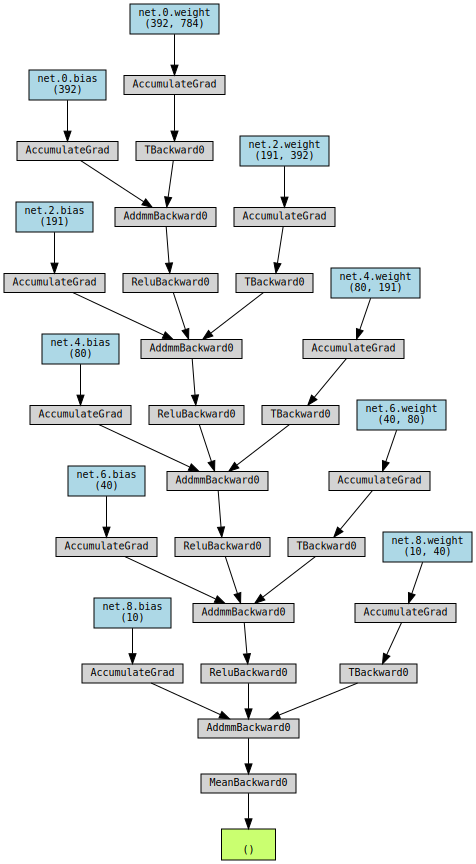

In [28]:
# Ещё вариант визуализации, если хочется блок-схему для графа вычислений
x = torch.randn(1, 784)
y = model(x)

# Среднее нужно, чтобы посчитать псевдолосс (одно число, которое мы как будто бы оптимизируем, но это просто среднее выходов нашей сети). Из логитов делаем одно число → как будто бы loss
make_dot(y.mean(), params=dict(model.named_parameters()))

#### Применение

Попробуем взять батч, который мы определили выше, и пропустить его через нашу сеть.

In [ ]:
# Подаём батч в сеть
model(X).shape
# Всё работает

torch.Size([64, 10])

Можно воспользоваться `forward`, но удобнее просто обращаться по `self`.

In [ ]:
# Всё совпадает
(model(X) == model.forward(X)).all()

tensor(True)

## Решение задачи

Теперь нам надо определить:
* оптимизатор,
* функцию потерь,
* количество эпох.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1) # Наш оптимизатор
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации
epochs = 10

Запускаем функцию обучения.

In [ ]:
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)

100%|██████████| 40/40 [00:00<00:00, 105.51it/s]


Эпоха: 0 | Train Loss 0.905122658287511 | Val Loss 0.22587140761315827


100%|██████████| 40/40 [00:00<00:00, 124.91it/s]


Эпоха: 1 | Train Loss 0.15961927995125447 | Val Loss 0.12542100759455935


100%|██████████| 40/40 [00:00<00:00, 120.52it/s]


Эпоха: 2 | Train Loss 0.09940157041128564 | Val Loss 0.10433112295577301


100%|██████████| 40/40 [00:00<00:00, 67.38it/s]


Эпоха: 3 | Train Loss 0.07283912612057677 | Val Loss 0.08344315502035898


100%|██████████| 40/40 [00:00<00:00, 119.61it/s]


Эпоха: 4 | Train Loss 0.056963709680504654 | Val Loss 0.07967552775080551


100%|██████████| 40/40 [00:00<00:00, 114.61it/s]


Эпоха: 5 | Train Loss 0.04208365050624074 | Val Loss 0.07980857037764508


100%|██████████| 40/40 [00:00<00:00, 113.13it/s]


Эпоха: 6 | Train Loss 0.033398954102780924 | Val Loss 0.08307441728411503


100%|██████████| 40/40 [00:00<00:00, 115.69it/s]


Эпоха: 7 | Train Loss 0.02614372562658188 | Val Loss 0.0820908788977249


100%|██████████| 40/40 [00:00<00:00, 120.35it/s]


Эпоха: 8 | Train Loss 0.021291584652757115 | Val Loss 0.09965308689570522


100%|██████████| 40/40 [00:00<00:00, 118.13it/s]

Эпоха: 9 | Train Loss 0.01977910159935876 | Val Loss 0.08147938729453018


**Вопрос.** На какой эпохе модель показала наилучший результат?



Выберем лучшую модель по валидации и загрузим её!

In [ ]:
# Не всегда последняя эпоха оказывается лучшей
model.load_state_dict(torch.load('/content/model_epoch_1_2_3_4_5_6_7_8_9.pth')) # Выберем эпоху

<ipython-input-67-0cf129030064>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/model_epoch_7.pth'))


<All keys matched successfully>

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
# Не всегда последняя эпоха оказывается лучшей
model.load_state_dict(torch.load('/content/model_epoch_9.pth')) # Выберем эпоху

<All keys matched successfully>

### Задание 7

С помощью загруженной модели получи предсказания.

In [ ]:
# Сначала положи модель на нужное устройство, потому что вновь загруженная модель используется по умолчанию на CPU

preds, _ = # Примени validate

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
# Сначала положим модель на нужное устройство, потому что вновь загруженная модель используется по умолчанию на CPU
model.to(device)
preds, _ = validate(model, loss, device, test_dl)

100%|██████████| 40/40 [00:00<00:00, 113.88it/s]


Посмотрим, совпадают ли предсказания с картинками.

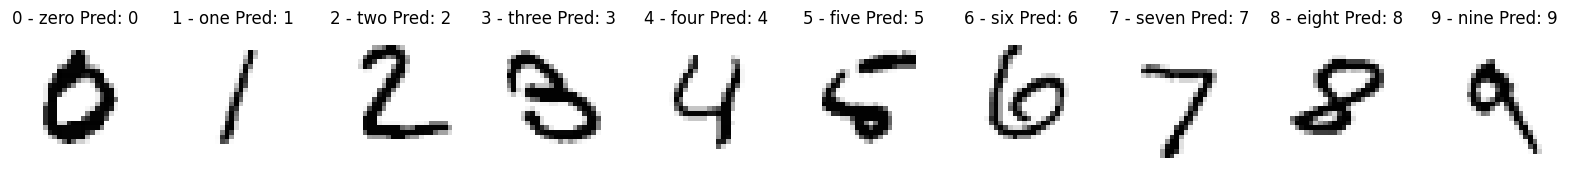

In [ ]:
show_ds(test, preds=preds)

Ура, выглядит неплохо!

## Дообучение



Как мы увидели, обучение нейросетей занимает время. Даже на небольшом датасете нам приходилось ждать, пока нейросеть обучится. В реальных же задачах данные могут быть другими:
- существенно больше по объёму;
- более сложными по своей природе — устройству и содержанию.

Следовательно, для решения задачи нужна другая нейросеть — более глубокая и сложная, с большим числом настраиваемых параметров. Чтобы немного сэкономить время и вычислительные мощности, можно прибегнуть к хитрости. Представим, что у нас уже есть модель, которая умеет решать похожую задачу.

Например, отличать друг от друга геометрические фигуры. Можно предположить, что модель научилась детектировать различные части фигур — острые палочки, закругления, спиральки, сокрестия и так далее. Следовательно, если немного подправить её веса и адаптировать под нашу задачу, модель сможет неплохо с ней справиться.

### Основные стратегии дообучения

В зависимости от архитектуры дообучаемой модели, можно выбрать одну из трёх стратегий дообучения — заморозку Backbone и обучение головы, частичное дообучение или полное обучение.


#### Стратегия 1. Заморозка Backbone + обучение головы (Feature Extractor)

> **Описание стратегии.** Все слои модели, кроме последнего (Head), заморожены. Далее выбирают, что обучать:
> - новый финальный слой;
> - свою «голову» из одного или нескольких полносвязных слоёв, которую поставили поверх модели.

Стратегию используют:

* когда мало данных;

* задача похожа на исходную.

**Плюсы:**

* высокая скорость;

* минимальный риск переобучения;
<!--* Легко объяснять и реализовывать -->

* доступность — её легко объяснить и реализовать.

**Минусы:**

<!--* Ограниченный потолок качества -->

* предел по росту качества.


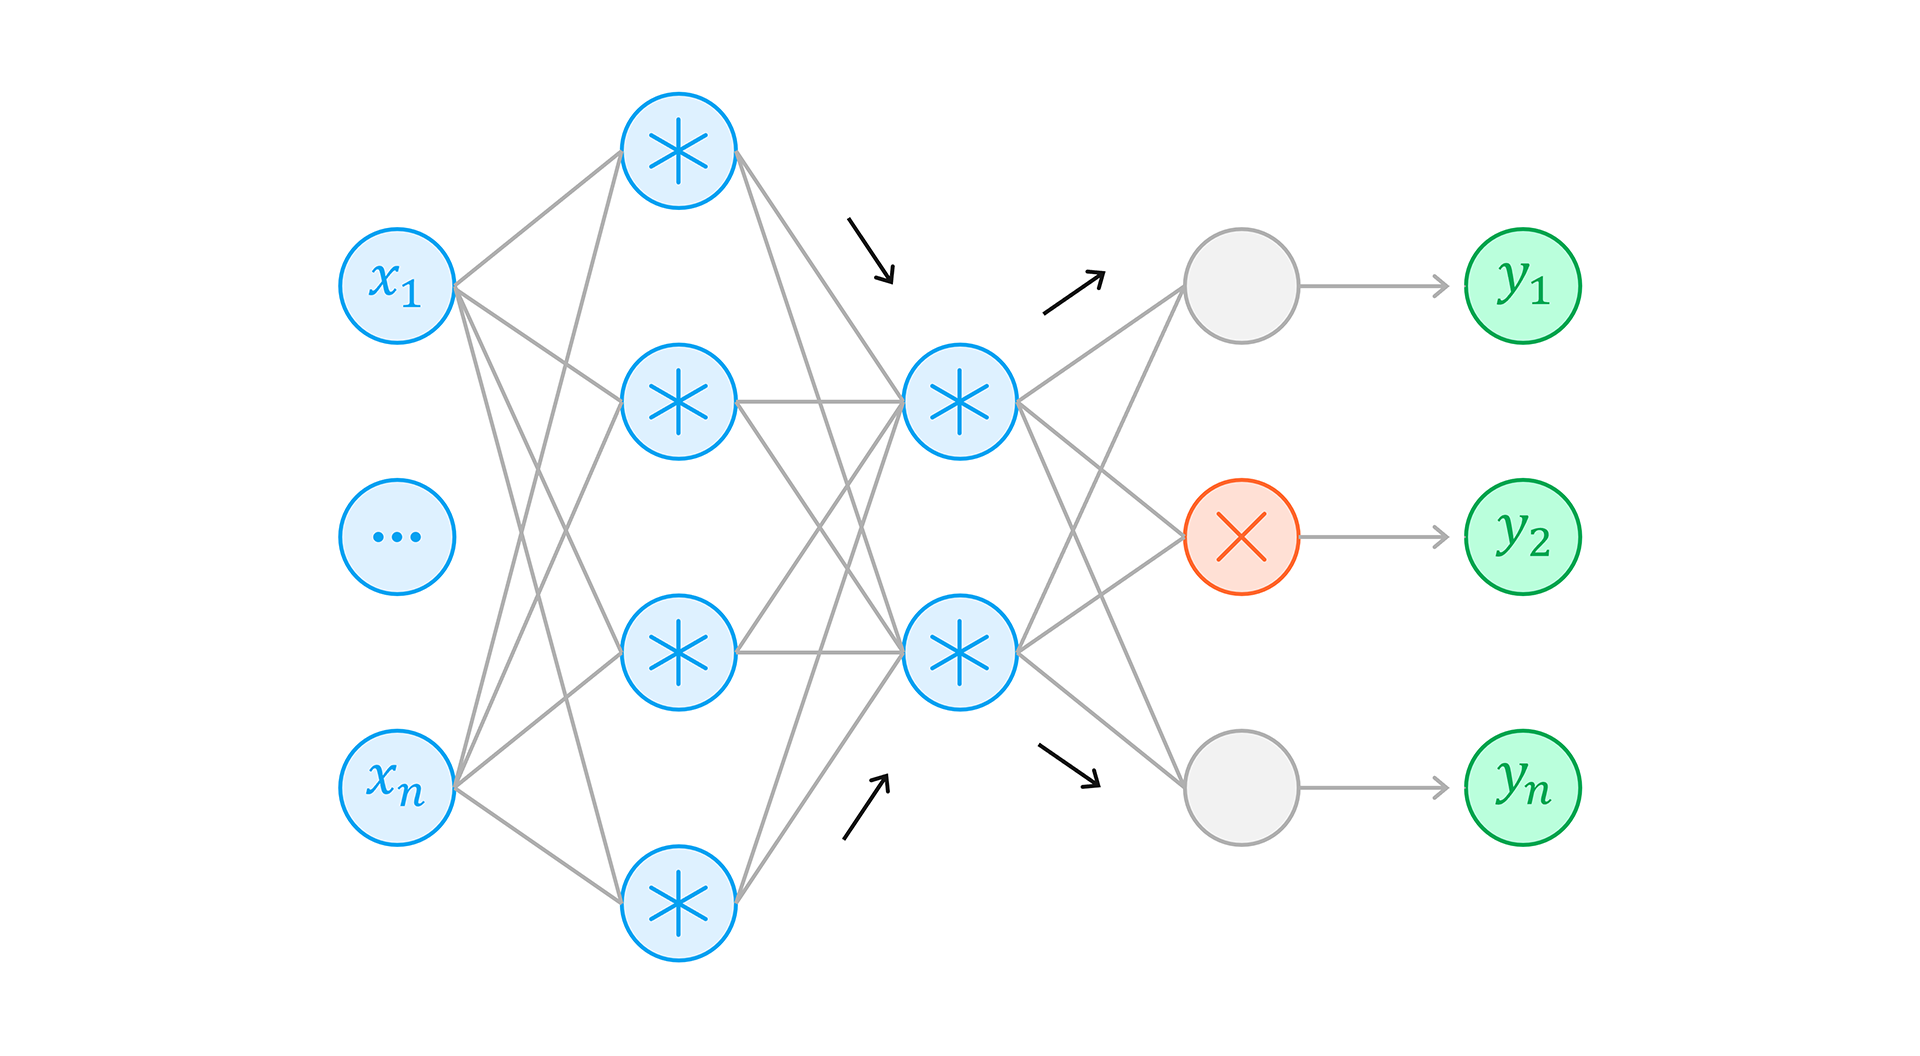

#### Стратегия 2. Частичное дообучение

>**Описание стратегии.** Поначалу Backbone заморожен, но затем размораживают последние блоки и дообучают их вместе с головой.

Стратегию используют:

 * когда данных немного;

 * задачи похожи, но обучение головы не дало нужного качества.

**Плюсы:**

* высокая скорость;

* модель лучше адаптируется к новым данным.

**Минусы:**

* при неаккуратной настройке learning rate (lr) или неправильном подборе базовой модели легко перетереть (забыть) уже выученные закономерности.

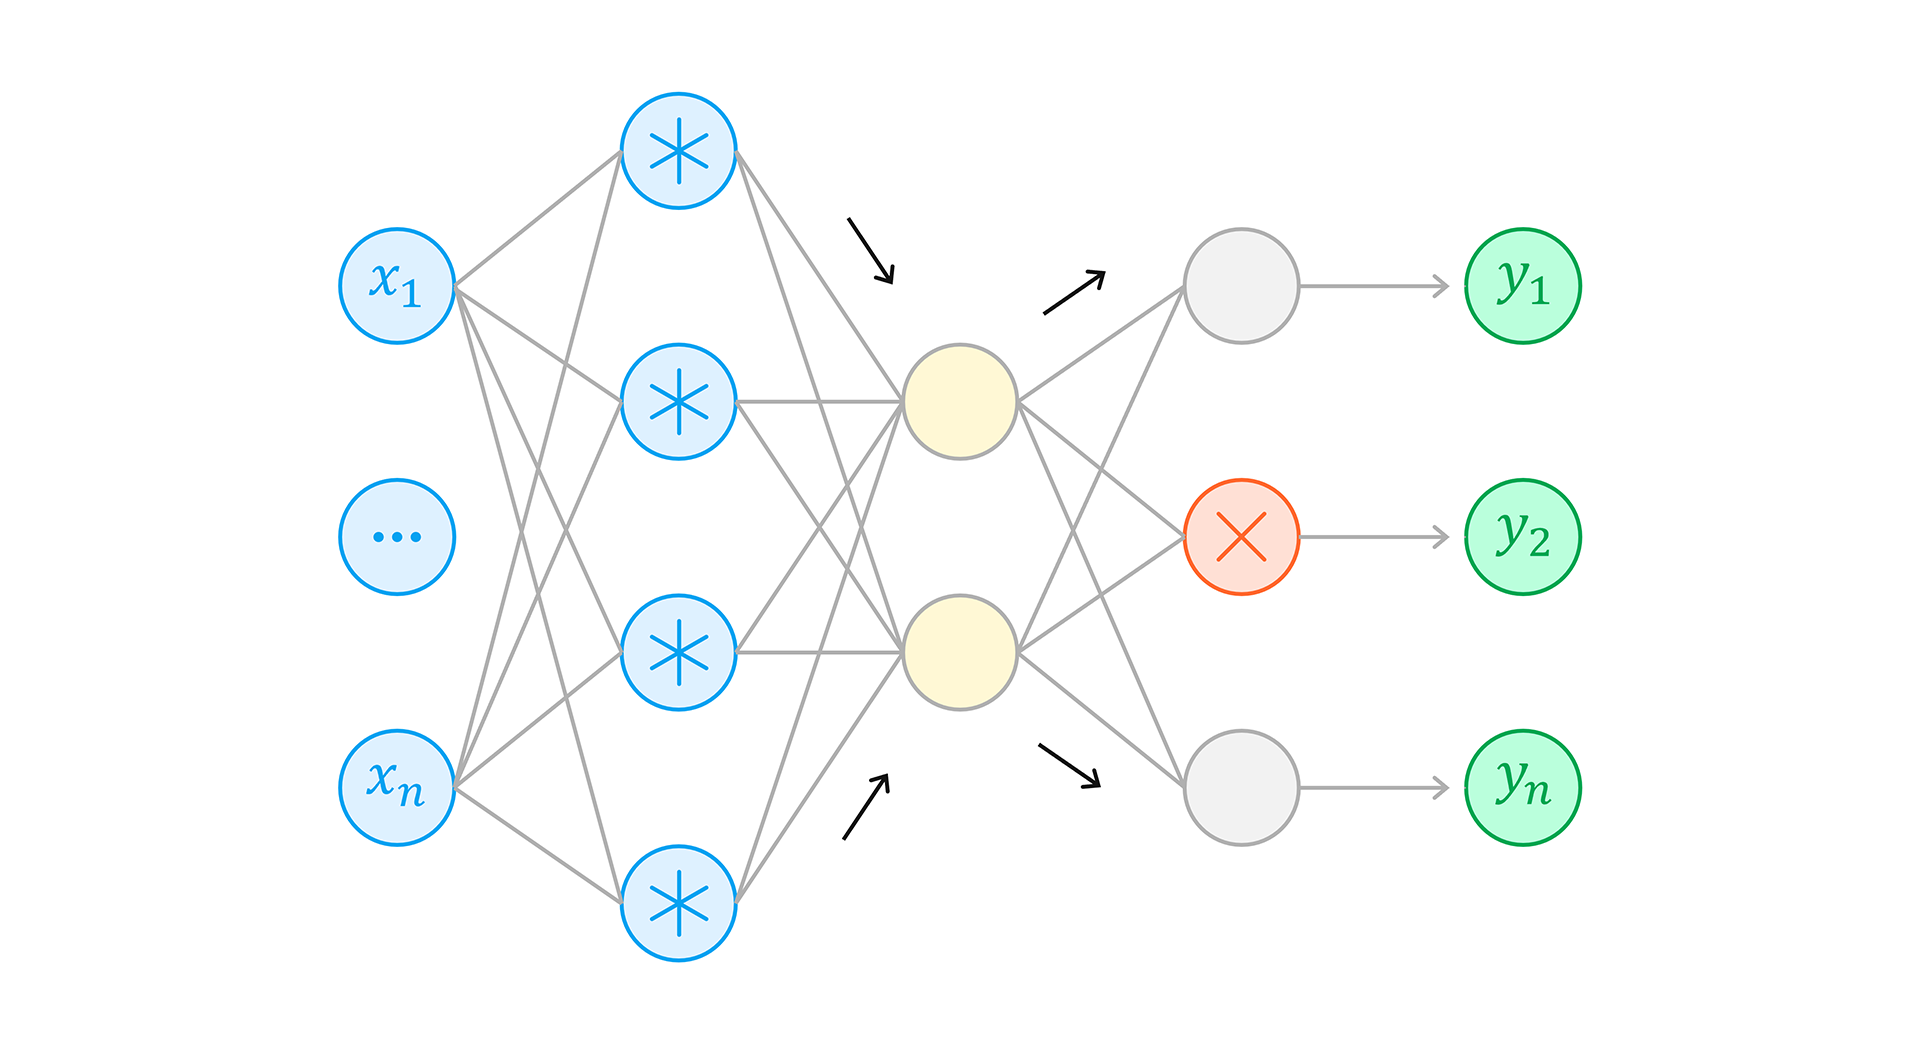

#### Стратегия 3. Полное обучение

> **Описание стратегии.** Изменяют все веса модели, но аккуратно — с небольшим learning rate.

Стратегию используют:

 * когда данных много;

 * задачи похожи, но наша задача имеет существенные особенности.

**Плюсы:**

* выдаёт наилучшее качество;

* модель получает все ресурсы для адаптации к новым данным.

**Минусы:**

* при неаккуратной настройке lr или неправильном подборе базовой модели легко перетереть уже выученные закономерности;

* высокие расходы на обучение.

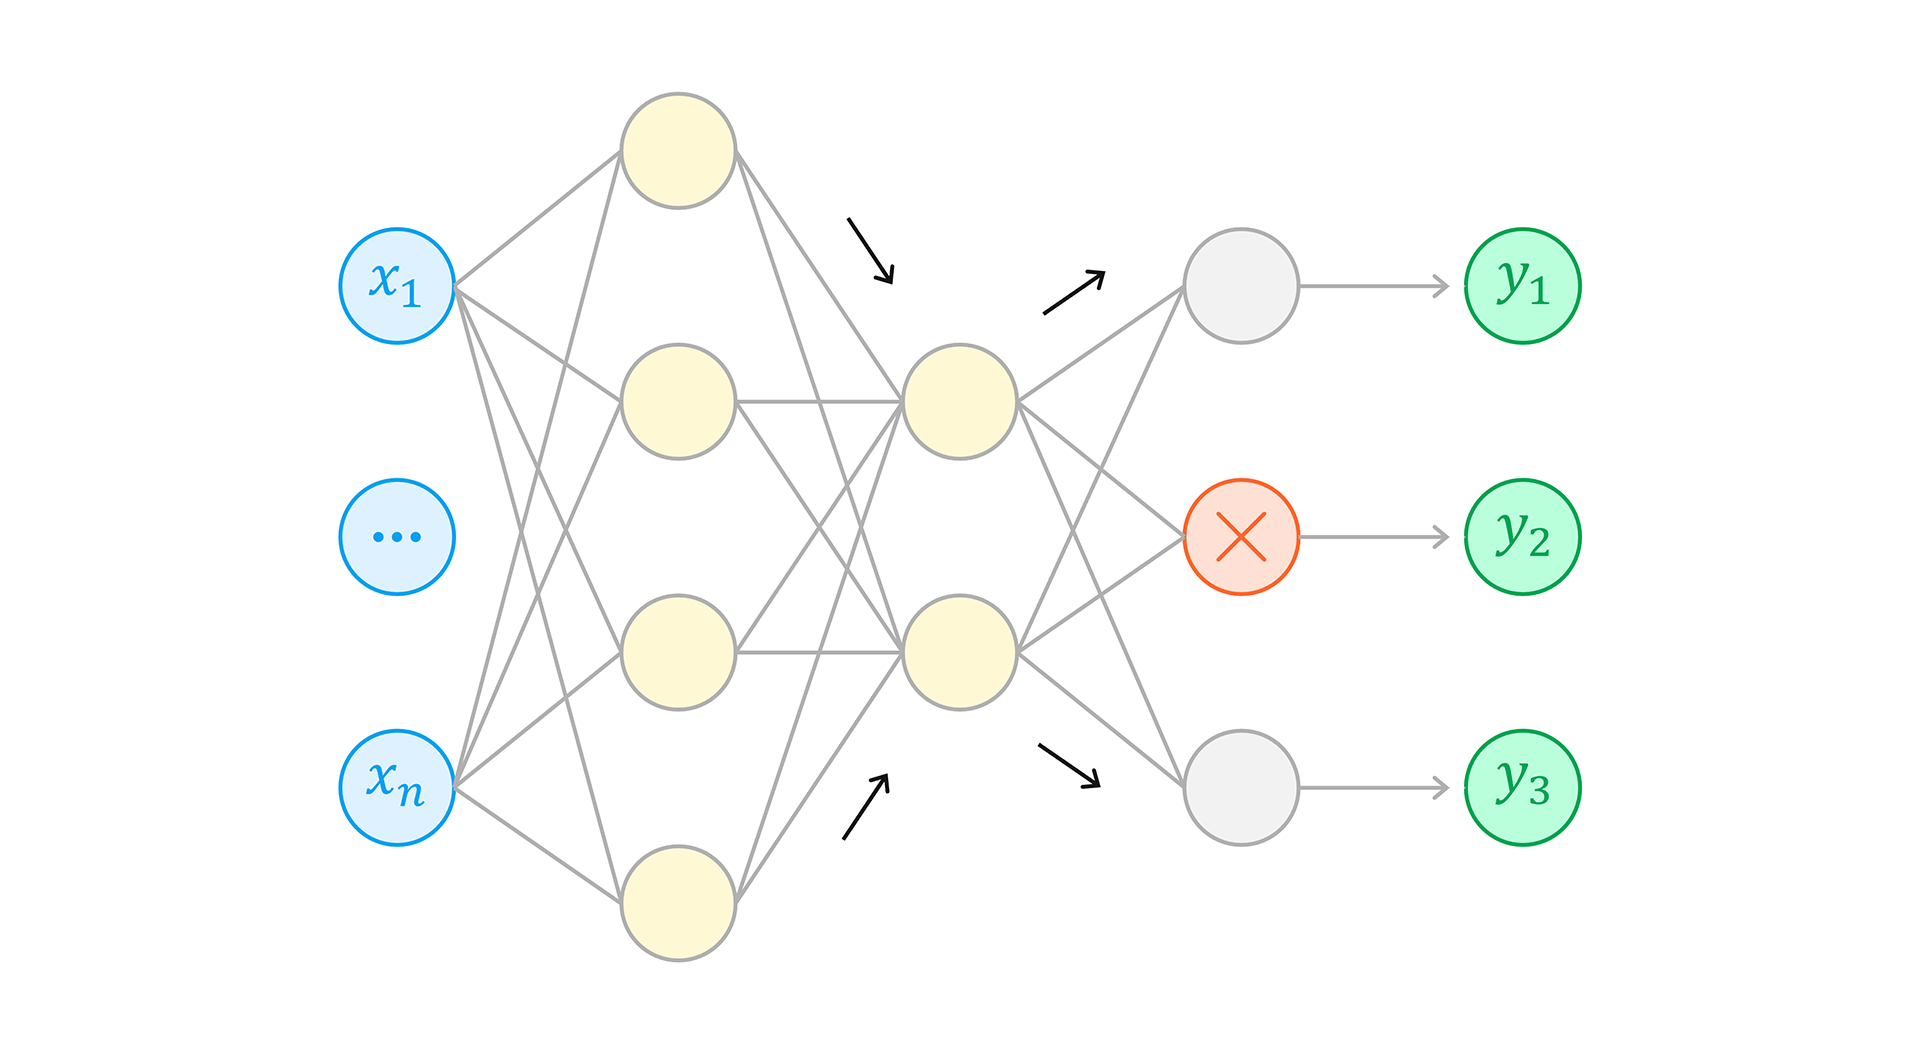

> **Примечание.** Мощные модели для разных задач можно найти на [Hugging Face](https://huggingface.co/).

Сейчас же в учебных целях попробуем повторно обучить нашу модель, сохранить её веса и дообучить.

In [ ]:
final_model = FCMNIST() # Модель
device = 'cuda' if torch.cuda.is_available() else 'cpu'
final_model = final_model.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(final_model.parameters(), lr=1e-1)
epochs_final = 3

train_and_validate(epochs_final, final_model, loss_fn, optimizer, device, train_dl, test_dl)
print("Финальная модель обучена!")

100%|██████████| 40/40 [00:00<00:00, 70.20it/s]


Эпоха: 0 | Train Loss 0.8878656672542419 | Val Loss 0.2302752917632461


100%|██████████| 40/40 [00:00<00:00, 99.20it/s]


Эпоха: 1 | Train Loss 0.16843207930329018 | Val Loss 0.16091000379528853


100%|██████████| 40/40 [00:00<00:00, 95.31it/s]

Эпоха: 2 | Train Loss 0.10605980833920799 | Val Loss 0.10315805497812106
Финальная модель обучена!


In [ ]:
# В нашей модели последний слой final_model.net[-1] == Linear(40, 10) и его ключи в state_dict: "net.8.weight", "net.8.bias"
state = final_model.state_dict()
head_prefix = "net.8."
state_wo_head = {k: v.cpu() for k, v in state.items() if not k.startswith(head_prefix)} # Сохраним все веса, кроме последнего слоя, чтобы было что дообучать

save_path = "fcmnist_backbone_no_head.pth"
torch.save(state_wo_head, save_path) # Специальная функция
print(f"Сохранено: {save_path} (без параметров слоя {head_prefix}*)")

Сохранено: fcmnist_backbone_no_head.pth (без параметров слоя net.8.*)


In [ ]:
# «Скачиваем» и восстанавливаем модель
loaded_state_wo_head = torch.load(save_path, map_location="cpu")

ft_model = FCMNIST()
missing, unexpected = ft_model.load_state_dict(loaded_state_wo_head, strict=False)

print("Загружены веса без головы.")
print("Missing keys (в нашем случае пропущена голова):", missing)
print("Unexpected keys:", unexpected)

Загружены веса без головы.
Missing keys (это нормально, это и есть голова): ['net.8.weight', 'net.8.bias']
Unexpected keys: []


In [ ]:
# Замораживаем всё, кроме последнего слоя, и дообучаем ТОЛЬКО голову на том же датасете
for p in ft_model.parameters():
    p.requires_grad = False

for p in ft_model.net[-1].parameters():   # Последний Linear
    p.requires_grad = True

ft_model = ft_model.to(device)

optimizer_head = torch.optim.SGD(ft_model.net[-1].parameters(), lr=1e-1)
epochs_head = 2


train_and_validate(epochs_head, ft_model, loss_fn, optimizer_head, device, train_dl, test_dl)
print("\nДообучили только финальный слой (⁀ᗢ⁀) ")


100%|██████████| 40/40 [00:00<00:00, 96.32it/s]


Эпоха: 0 | Train Loss 0.09735895249308776 | Val Loss 0.08885488460073247


100%|██████████| 40/40 [00:00<00:00, 101.06it/s]

Эпоха: 1 | Train Loss 0.06165186217026899 | Val Loss 0.08919859546585937

Дообучили только финальный слой


100%|██████████| 40/40 [00:00<00:00, 101.71it/s]


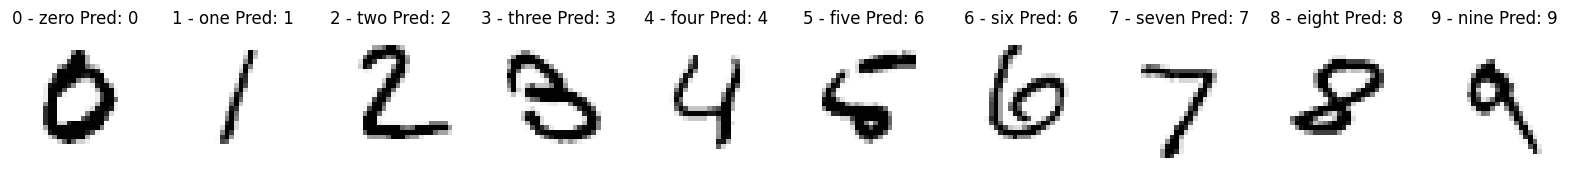

In [ ]:
preds, _ = validate(ft_model, loss, device, test_dl)
show_ds(test, preds=preds)

## Хуки и затухание градиента

Когда нужно получить данные с конкретного слоя и не менять вручную forward, можно воспользоваться готовым инструментом — хуками.

> **Хуки** (от англ. hooks) — это встроенные функции PyTorch, которые помогают извлекать данные из нейросети во время её работы.

Хуки помогают:

- извлекать промежуточные данные из forward;
- извлекать градиенты, которые получились при backward-подходе — обратном распространении ошибки;
- находить проблемные места в нейросети, например выявлять «затухание градиента».

Также с их помощью можно интерпретировать предсказания нейросети — изучить слои и выяснить, какие признаки повлияли на итоговое предсказание.

Определим хуки для нашей нейросети и посмотрим, как с их помощью можно выявить эффект «затухания градиента».

In [ ]:
# Будем всё сохранять в словарь
from collections import defaultdict

# Функция в функции нам нужна, чтобы передать параметр key и удобно сохранить информацию в словарь
# По умолчанию forward_hook принимает только input и output, a backward_hook — только grad

# Функция, создающая хуки, для прямого (forward) прохода. То есть когда мы подаём данные в нейросеть и ожидаем предсказания
def get_forward_hook(history_dict, key):
    def forward_hook(self, input_, output):
        # Из forward достаём input. То есть то, что входит в слой
        # output (выход из слоя) здесь нам вообще не нужен в данном случае, но для работы хука он должен быть как аргумент в функции
        # Перекладываем на СPU и убираем градиенты, чтобы перевести в NumPy. Потом всё вытягиваем в вектор
        history_dict[key] = input_[0].cpu().detach().numpy().flatten()
    return forward_hook

# Функция, создающая хуки, для обратного прохода (backward). То есть когда мы по полученным предсказаниям считаем функцию потерь и потом запускаем алгоритм обратного распространения ошибки
def get_backward_hook(history_dict, key):
    def backward_hook(grad):
        # Как в forward, но только значение градиентов берём по модулю. Нас интересует его величина, а не знак
        history_dict[key] = grad.abs().cpu().detach().numpy().flatten()
    return backward_hook

# Функция для создания хуков
def register_model_hooks(model):
    # Индекс нужен для нейминга слоёв
    cur_ind = 0
    # Данные, полученные из хуков, будем хранить в defaultdict
    hooks_data_history = defaultdict(list)
    # Итерируемся по слоям модели
    for child in model.net.children():
        # Будем смотреть только для линейных слоёв
        if isinstance(child, (nn.Linear)):
            # Так как брали для forward_hook вход, то это, по сути, будет выход ReLU
            forward_hook = get_forward_hook(hooks_data_history, f"act_out_{cur_ind}")
            # Регистрируем хуки методом torch для прямого прохода
            child.register_forward_hook(forward_hook)

            cur_ind += 1
            # Определяем backward-хуки
            backward_hook = get_backward_hook(hooks_data_history, f"gradient_linear_{cur_ind}")
            # И регистрируем их методом torch
            child.weight.register_hook(backward_hook)
    return hooks_data_history

In [ ]:
# Заново инициализируем модель, чтобы собрать данные для хуков во время обучения
model = FCMNIST()
# Регистрируем хуки
hooks_data_history = register_model_hooks(model)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1) # Наш оптимизатор
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации. Разбиралась на лекциях
epochs = 5

In [ ]:
# Обучаем модель как обычно. Хуки уже инициализированы внутри. Они всё сохранят
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)

100%|██████████| 40/40 [00:00<00:00, 79.37it/s]


Эпоха: 0 | Train Loss 0.8826995283651511 | Val Loss 0.2021647717338055


100%|██████████| 40/40 [00:00<00:00, 113.87it/s]


Эпоха: 1 | Train Loss 0.1686095246844383 | Val Loss 0.12531921872869137


100%|██████████| 40/40 [00:00<00:00, 116.68it/s]


Эпоха: 2 | Train Loss 0.1042745982733104 | Val Loss 0.08908669117663522


100%|██████████| 40/40 [00:00<00:00, 45.14it/s]


Эпоха: 3 | Train Loss 0.07588506566624992 | Val Loss 0.09181177057907919


100%|██████████| 40/40 [00:00<00:00, 115.32it/s]

Эпоха: 4 | Train Loss 0.05803623269739473 | Val Loss 0.09264653853606433


In [ ]:
# Функция для визуализации распределения значений функции активации и градиентов
def plot_hooks_data(hooks_data_history):

    # Получаем ключи для визуализации
    keys = hooks_data_history.keys()
    n_layers = len(keys) // 2

    # Делаем ключи, по которым будем обращаться к словарю
    activation_names = [f"act_out_{i}" for i in range(1, n_layers)]

    # Достаём по ключам активации на слоях
    activations_on_layers = [
        hooks_data_history[activation] for activation in activation_names
    ]

    # Делаем ключи, по которым будем обращаться к словарю
    gradient_names = [f"gradient_linear_{i + 1}" for i in range(n_layers)]
    # Достаём по ключам градиенты линейных слоёв
    gradients_on_layers = [hooks_data_history[gradient] for gradient in gradient_names]

    # В цикле рисуем boxplots
    for plot_name, values, labels in zip(
        ["activations", "gradients"],
        [activations_on_layers, gradients_on_layers],
        [activation_names, gradient_names],
    ):
        fig, ax = plt.subplots(1, len(labels), figsize=(14, 4), sharey="row")
        for label_idx, label in enumerate(labels):
            ax[label_idx].boxplot(values[label_idx], tick_labels=[label])
            if label_idx == 0:
              ax[label_idx].set_ylabel('Значение на выходе из блока')
        plt.show()

### Задание 8

1. Примени функцию для визуализации выходов разных слоёв нейросети.
2. Проинтерпетируй результаты. Ответь на вопрос: есть ли затухание градиентов?

In [ ]:
# Напиши код здесь

Напиши ответ на вопрос здесь.

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Эффект затухания градиента заметен. На последнем слое модели градиенты существенно больше, чем на первом. Тем не менее модель довольно неплохо выучила нашу выборку. Это значит, что влияние затухания градиента некритично — при его наличии модель справляется с задачей.

Это объясняется ещё и тем, что ReLU имеет производную $= 1$ на достаточно большом промежутке (правая полуось). Следовательно, при многократном вычислении этой функции активации градиенты менее склонны взрываться и затухать.

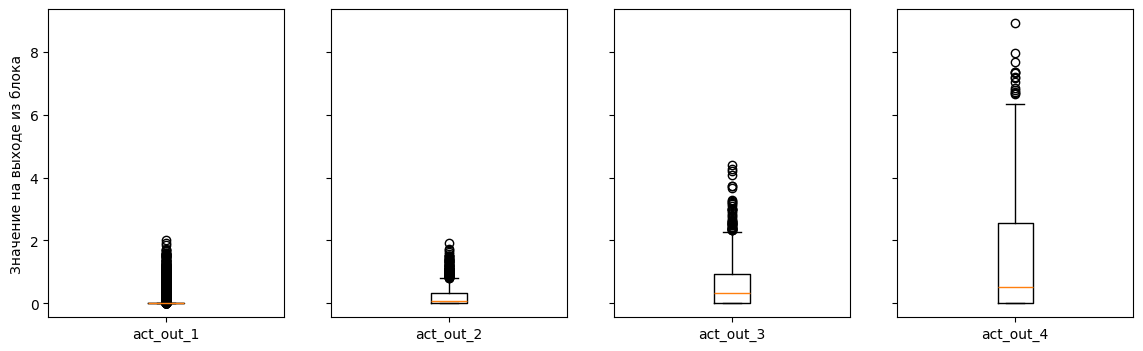

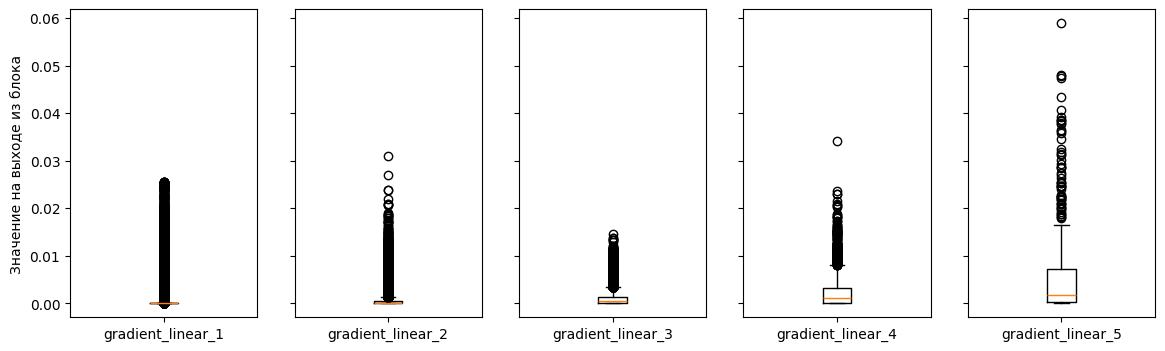

In [ ]:
# Применим нашу функцию для визуализации
plot_hooks_data(hooks_data_history)

### Задание 9

1. Создай класс SigmaFCMNIST, в котором вместо ReLU будет сигмоида.
2. Обучи нейросеть и посмотри — столкнёмся ли мы с проблемой затухания градиентов?

In [ ]:
# Напиши код здесь

Напиши свои выводы здесь.

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Теперь затухание градиента выражено максимально ярко. Это можно увидеть:

- по градиентам, которые уходят в 0 к первому слою;
- распределению данных на выходе из функции активации.

Для сигмоиды значение 0,5 в среднем значит, что она принимала на вход абсолютно случайные числа в районе 0. Это могло случиться лишь в одном случае — если применять необученные параметры к данным.

In [ ]:
class SigmaFCMNIST(nn.Module):

  def __init__(self):
    super().__init__() # Не забываем super init сделать, без этого ничего работать не будет

    # Линейный слой → Sigmoid → линейный слой → и так далее
    self.net = nn.Sequential(
        nn.Linear(784, 392),
        nn.Sigmoid(),
        nn.Linear(392, 191),
        nn.Sigmoid(),
        nn.Linear(191, 80),
        nn.Sigmoid(),
        nn.Linear(80, 40),
        nn.Sigmoid(),
        nn.Linear(40, 10)
    )

  def forward(self, X):
    return self.net(X)

In [ ]:
# Заново инициализируем модель, чтобы собрать данные для хуков во время обучения
model = SigmaFCMNIST()
# Регистрируем наши хуки
hooks_data_history = register_model_hooks(model)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
optimizer = torch.optim.SGD(model.parameters(), lr=1e-1) # Наш оптимизатор
loss = nn.CrossEntropyLoss() # Кросс-энтропия, самая популярная функция потерь для решения задачи классификации
epochs = 5

In [ ]:
# Обучаем модель как обычно. Хуки уже инициализированы внутри. Они всё сохранят
train_and_validate(epochs, model, loss, optimizer, device, train_dl, test_dl)

100%|██████████| 40/40 [00:00<00:00, 113.60it/s]


Эпоха: 0 | Train Loss 2.3055102774275045 | Val Loss 2.3061339557170863


100%|██████████| 40/40 [00:00<00:00, 112.32it/s]


Эпоха: 1 | Train Loss 2.304666989132083 | Val Loss 2.304738444089889


100%|██████████| 40/40 [00:00<00:00, 112.99it/s]


Эпоха: 2 | Train Loss 2.3039636853664875 | Val Loss 2.302145785093308


100%|██████████| 40/40 [00:00<00:00, 112.69it/s]


Эпоха: 3 | Train Loss 2.3037659997237783 | Val Loss 2.304219454526901


100%|██████████| 40/40 [00:00<00:00, 111.56it/s]

Эпоха: 4 | Train Loss 2.303328397561547 | Val Loss 2.3032976150512696


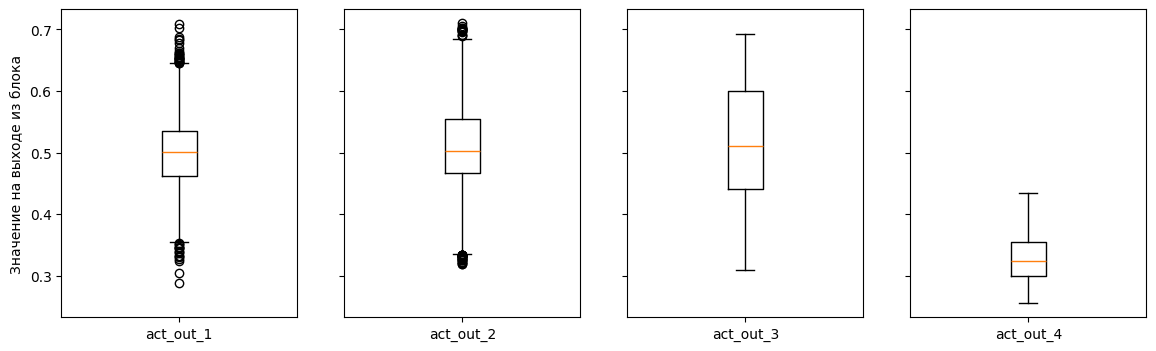

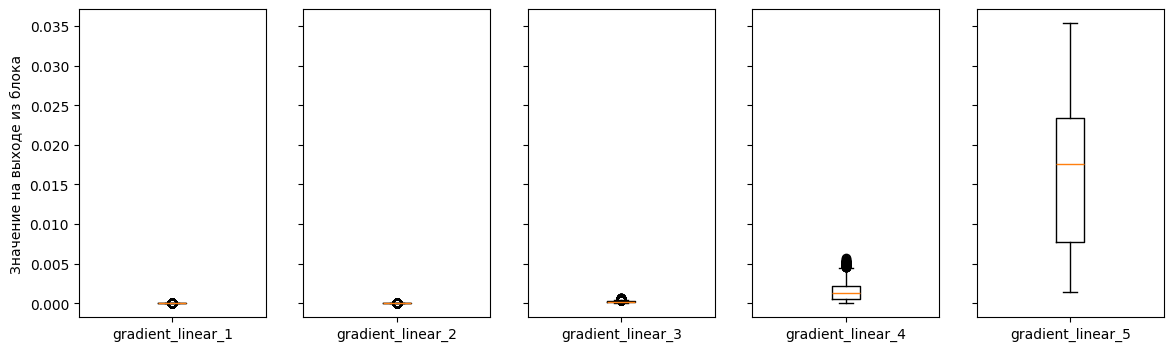

In [ ]:
# Делаем визуализацию
plot_hooks_data(hooks_data_history)

### Математическое объяснение затухания сигмоиды

Как мы помним, производная сигмоиды имеет вид
$$\sigma'(x) = \sigma(x) \cdot (1 - \sigma(x)).$$

Сигмоида — очень плавная функция, и в этом мы могли убедиться в домашнем задании. Вот её два важных свойства:

- выход лежит в интервале $(0,\ 1)$;
- производная всегда удовлетворяет условию
$0 < \sigma'(x) \leq 0{,}25.$



При этом максимальное значение $\sigma'(x) = 0{,}25$ достигается только при $x = 0$. Во всех остальных точках — производная строго меньше $0{,}25$, что ограничивает величину передаваемого градиента.


**Что происходит при backprop**

Как мы помним с лекции, при обратном распространении ошибки градиент, передаваемый на слой, выражается через произведение производных и весов по всем последующим слоям:
$$\frac{\partial L}{\partial w_l} = \frac{\partial L}{\partial y} \cdot \prod_{k=l}^{L} \left( \sigma'(z_k) \cdot w_k \right).$$

Если веса $w_k$ по модулю не превышают $1$, а производные $\sigma'(z_k) \leq 0{,}25$, то произведение быстро стремится к нулю с увеличением глубины сети.